# Lesson 153 · Recommendation portfolio: rank candidates without temporal leakage

Teacher solution · PROVIDED / TODO / CHECK / EXIT. Default: CPU audit of real author evidence. Post-EXIT: full visible released pipeline and separate pinned GPU gate. TierB benchmark; synthetic fixtures only isolate mechanisms. Install torch, torch-geometric, pytorch-frame, numpy and pandas for the CPU lane; use the embedded pinned requirements and Modal recipe for reproduction. No source checkout or pre-existing data folder is needed.

<!-- course-portable:start -->
### Follow the computation

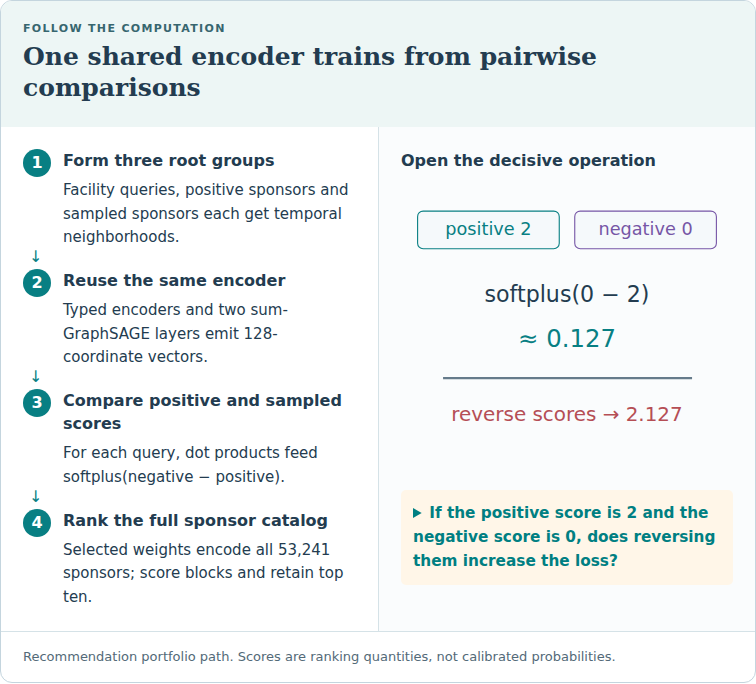

Recommendation portfolio path. Scores are ranking quantities, not calibrated probabilities.

**Trace question:** If the positive score is 2 and the negative score is 0, does reversing them increase the loss?

**Trace answer:** Yes: softplus(−2) ≈ 0.127 becomes softplus(2) ≈ 2.127.
<!-- course-portable:end -->

In [1]:
# PROVIDED: default CPU audit; full reproduction needs the exact CUDA runtime.
import os,sys
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
from pathlib import Path
import math,statistics,json,io,base64,hashlib,zlib,gzip,copy,time
import numpy as np,pandas as pd,torch
from IPython.display import display
RUN_FULL_REPRODUCTION=False


In [2]:
# PROVIDED: compressed source/evidence transport; executable pipeline is visible below.
SOURCE_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
P=Path.cwd()
for name,text in SOURCE_FILES.items():
 dest=P/name;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_text(text)
sys.path.insert(0,str(P))
AUTHOR_SUMMARY={'status': 'PASS', 'full_selected_reproduction': 'INCOMPLETE', 'paper_comparison': 'NOT_RUN', 'pilot': {'status': 'PARTIAL_TIMING_PILOT', 'seed': 0, 'protocol_hash': '38c8e76ea6e3e8b0f7b25d665e09cb4371ff211016f11ab4c4a155ff9efc4504', 'selected_epoch': 1, 'trace': [{'epoch': 1, 'train_loss': 0.2539881963748485, 'val_map': 0.007062706669095564, 'train_seconds': 38.18756106000001, 'validation_seconds': 20.110556777, 'seconds': 58.298120686000004}], 'scores': {'val': 0.010508151025656524}, 'counts': {'val': 37003}, 'temporal_violations': 0, 'audit': {'batches': 450, 'queries': 229640, 'dated_node_occurrences': 4503923, 'edge_occurrences': 6783360, 'temporal_violations': 0, 'train_batches': 32, 'negative_comparisons': 8388608, 'positive_collisions': 356, 'negative_audit_batches': 32, 'availability': 'NOT_OBSERVED'}, 'first_batch_nonfinite_gradients': {'encoder.encoders.studies.encoder.encoder_dict.numerical.weight': 384}, 'source_sha256': 'becfaef38e031abccb03cd20f3e384247f5bba767d359b2a22056782c4b12916', 'executed_sha256': 'e0d15dab298444bfe672c68401564d84bda1c34781dedda04d0530803de9d906', 'loader_batches': 1299, 'training_queries_per_full_epoch': 665088, 'val_metrics': {'n': 37003, 'map': 0.010508151025656524, 'hit': 0.07039969732183878, 'recall': 0.05648286002633861}, 'checkpoint_sha256': '42b8f0603493735b6588ff21831cc0059287058442be29670636fd0b63ce99b6', 'original_model_max_abs': 2.384185791015625e-07, 'seconds': 199.246320725}, 'records': [], 'portfolio': None, 'independently_rescored_rankings': 37003, 'independent_metrics': {'pilot': {'val': {'map': 0.010508151025656524, 'hit': 0.07039969732183878, 'recall': 0.05648286002633861, 'n': 37003}}}, 'labels': {'status': 'PASS', 'independently_rebuilt_queries': {'train': 669310, 'val': 37003, 'test': 27428}, 'interval': '(cutoff,cutoff+365days]', 'join': 'facility-study dates; sponsor-study nct_id; no sponsor date filter'}, 'prepared': {'graph_sha256': '4f683211d33360e9ad293c0189fddad940223788ce1d616db800ed72766b9eb7', 'counts': {'train': 669310, 'val': 37003, 'test': 27428}, 'rows': {'conditions': 3973, 'conditions_studies': 408422, 'designs': 249093, 'drop_withdrawals': 381199, 'eligibilities': 249730, 'facilities': 453233, 'facilities_studies': 1798765, 'interventions': 3462, 'interventions_studies': 171771, 'outcome_analyses': 225846, 'outcomes': 411933, 'reported_event_totals': 383064, 'sponsors': 53241, 'sponsors_studies': 391462, 'studies': 249730}, 'eval_k': 10, 'num_dst_nodes': 53241, 'src': 'facilities', 'dst': 'sponsors', 'stypes': {'conditions': {'mesh_term': 'text_embedded'}, 'conditions_studies': {'date': 'timestamp'}, 'designs': {'allocation': 'categorical', 'intervention_model': 'categorical', 'observational_model': 'text_embedded', 'primary_purpose': 'text_embedded', 'time_perspective': 'text_embedded', 'masking': 'categorical', 'masking_description': 'text_embedded', 'intervention_model_description': 'text_embedded', 'subject_masked': 'categorical', 'caregiver_masked': 'categorical', 'investigator_masked': 'categorical', 'outcomes_assessor_masked': 'categorical', 'date': 'timestamp'}, 'drop_withdrawals': {'period': 'text_embedded', 'reason': 'text_embedded', 'count': 'numerical', 'date': 'timestamp'}, 'eligibilities': {'sampling_method': 'categorical', 'gender': 'categorical', 'minimum_age': 'text_embedded', 'maximum_age': 'text_embedded', 'healthy_volunteers': 'categorical', 'population': 'text_embedded', 'criteria': 'text_embedded', 'gender_description': 'text_embedded', 'gender_based': 'categorical', 'adult': 'categorical', 'child': 'categorical', 'older_adult': 'categorical', 'date': 'timestamp'}, 'facilities': {'name': 'text_embedded', 'city': 'text_embedded', 'state': 'text_embedded', 'zip': 'text_embedded', 'country': 'text_embedded'}, 'facilities_studies': {'date': 'timestamp'}, 'interventions': {'mesh_term': 'text_embedded'}, 'interventions_studies': {'date': 'timestamp'}, 'outcome_analyses': {'non_inferiority_type': 'categorical', 'non_inferiority_description': 'text_embedded', 'param_type': 'text_embedded', 'param_value': 'numerical', 'dispersion_type': 'categorical', 'dispersion_value': 'numerical', 'p_value_modifier': 'categorical', 'p_value': 'numerical', 'ci_n_sides': 'categorical', 'ci_percent': 'numerical', 'ci_lower_limit': 'numerical', 'ci_upper_limit': 'numerical', 'ci_upper_limit_na_comment': 'text_embedded', 'p_value_description': 'text_embedded', 'method': 'text_embedded', 'method_description': 'text_embedded', 'estimate_description': 'text_embedded', 'groups_description': 'text_embedded', 'other_analysis_description': 'text_embedded', 'date': 'timestamp'}, 'outcomes': {'outcome_type': 'text_embedded', 'title': 'text_embedded', 'description': 'text_embedded', 'time_frame': 'text_embedded', 'population': 'text_embedded', 'units': 'text_embedded', 'units_analyzed': 'text_embedded', 'dispersion_type': 'text_embedded', 'param_type': 'text_embedded', 'date': 'timestamp'}, 'reported_event_totals': {'event_type': 'categorical', 'classification': 'categorical', 'subjects_affected': 'numerical', 'subjects_at_risk': 'numerical', 'date': 'timestamp'}, 'sponsors': {'name': 'text_embedded', 'agency_class': 'text_embedded'}, 'sponsors_studies': {'lead_or_collaborator': 'categorical', 'date': 'timestamp'}, 'studies': {'start_date': 'timestamp', 'target_duration': 'text_embedded', 'study_type': 'categorical', 'acronym': 'text_embedded', 'baseline_population': 'text_embedded', 'brief_title': 'text_embedded', 'official_title': 'text_embedded', 'phase': 'categorical', 'enrollment': 'numerical', 'enrollment_type': 'categorical', 'source': 'text_embedded', 'number_of_arms': 'numerical', 'number_of_groups': 'numerical', 'has_dmc': 'categorical', 'is_fda_regulated_drug': 'categorical', 'is_fda_regulated_device': 'categorical', 'is_unapproved_device': 'categorical', 'is_us_export': 'categorical', 'biospec_retention': 'text_embedded', 'biospec_description': 'text_embedded', 'source_class': 'text_embedded', 'baseline_type_units_analyzed': 'text_embedded', 'plan_to_share_ipd': 'categorical', 'detailed_descriptions': 'text_embedded', 'brief_summaries': 'text_embedded'}}, 'database_files': {'db/conditions.parquet': 'b20a0587669ee1510894e972e1a446853cf95d29c75767c54af062729ac99165', 'db/conditions_studies.parquet': '75698f9ec4a974f014908ed081bb82182f83dd2cc641460ef63ff3dc79ad566f', 'db/designs.parquet': '8e99e554fd1af1b2fc6190499cff1b3f77ac0009bcb340f825ced32e902c4f01', 'db/drop_withdrawals.parquet': '54d9ae12fec62b4bc012ab559ca2f25c3384b14680c015b23d889e82f992fcac', 'db/eligibilities.parquet': '2aa1d59de34c0f2663e2e3b0c775509cf6c0ac94968d1eb93d4dd10cb0727f95', 'db/facilities.parquet': '91aedddec9c152a206ea90b8542cbad1f80cde3746e8a744cca309adbebc306e', 'db/facilities_studies.parquet': 'aeabc54009526a785a49607a29997c6912ad87fe1b754c4bfd2926e2b9983bab', 'db/interventions.parquet': '04961aa2e74f9d95f4c5549e94877b9d08228c614ac1800ccc5d8bf6c5633d22', 'db/interventions_studies.parquet': '6493b1c15200410529abf7eeea8ecd604a2118ff0af4942445e2c50623129a24', 'db/outcome_analyses.parquet': '6abe400ce0d12fcda76884b0db8b9a3e86b8d39e2d3f928bc59f091cf02dfc77', 'db/outcomes.parquet': '48190f0b0d64f26e42767becf6cf17b7ceeefa5fcac88a18cd59be44ceaf71e4', 'db/reported_event_totals.parquet': '92875acf347300a3eae9db0d8f5474604acbadf0259d9b252cd56c862c5f34e7', 'db/sponsors.parquet': '5943db2240572453441e7872064022eb6778ffb23adba07a37c33e66810dbda2', 'db/sponsors_studies.parquet': '5b1dc4cadc7b0116221a0200f6e18e5a28e4b48340028dfcdbd4782c9684ec1b', 'db/studies.parquet': '2419b0016e60c5423d5f1f9e58ea22dd7ab545aae238f11472250253bd53dbae', 'tasks/site-sponsor-run/test.parquet': 'ff433eea14d343ff5190c66208f6e5dac19bd85acbb7f1ea03a6dee3e5a796e5', 'tasks/site-sponsor-run/train.parquet': '2bfdfbeab499b765775a08ab487042b8c21b6f5d9cfde1ecae1e638a853fa71c', 'tasks/site-sponsor-run/val.parquet': 'b227480b05125dd4956d1bf0c038057aa6d0b8f8b6c698e045e8dbbfcdc89a21'}, 'task_files': {'test.parquet': 'ff433eea14d343ff5190c66208f6e5dac19bd85acbb7f1ea03a6dee3e5a796e5', 'train.parquet': '2bfdfbeab499b765775a08ab487042b8c21b6f5d9cfde1ecae1e638a853fa71c', 'val.parquet': 'b227480b05125dd4956d1bf0c038057aa6d0b8f8b6c698e045e8dbbfcdc89a21'}, 'archive_hashes': {'db.zip': '9fb5ba14f7cbca8115f3dfe0800415f98d6ddc15561e56c35ee614da6b89552a', 'tasks/site-sponsor-run.zip': '64c8b039b81d45b708e85c71c319e95372dd8f9a832e4255aad448ca0fe0a879'}}, 'worker_body_usd': 0.28571603686336955, 'costs': {'pilot-cost.json': {'seconds': 200.153439732, 'worker_body_usd': 0.05228808459558768}, 'prepare-cost.json': {'seconds': 893.538325937, 'worker_body_usd': 0.23342795226778185}}, 'historical_identity': 'NOT_ESTABLISHED', 'feature_arrival_legality': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN', 'fresh_manual_fe': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE', 'live_colab': 'NOT_CHECKED', 'deployment': 'NOT_CHECKED'}
COST_DECISION={'decision': 'STOP', 'pilot_training_batches': 32, 'full_training_batches': 1299, 'pilot_training_seconds': 38.18756106000001, 'full_validation_seconds': 20.110556777, 'projected_per_fit_seconds': 31566.796030792506, 'projected_five_run_compute_usd': 41.23254897542117, 'safety_adjusted_per_fit_seconds': 39578.49503849063, 'safety_adjusted_five_runs_and_validation_usd': 51.854174219276466, 'remaining_compute_allowance_usd': 6.059536, 'assumption': '20epochs; full released timestamp batches;22full-validation-equivalent evaluation passes;1.25safety plus120s per fit; conservative first32batch audit/cold-start cost. Scenario estimate, not lower bound.', 'full_dispatch_timeout_seconds': 4200, 'budget_usd': 10}
PAYLOAD={'pilot': {'data': '...', 'sha256': 'f1e5a07e60262d30ff5a7713ad6151f91f3507683a328ad267ef6aa2257b9555'}}
TRUTH_PACKET={'val': '...', 'test': '...'}


## 1 · From one answer to an ordered list

**Reading route.** Fix the candidate population → trace shared encoders → audit sampled negatives → calculate AP → report completion.

**Your win:** produce portfolio entry 3 with a defensible candidate population, ranking metric, temporal audit and reproduction verdict. The core lesson takes about 20 minutes; the lab and optional full experiment are separate sessions.

[Lesson 151](https://avistian.github.io/relational/lessons/0151-classification-portfolio.html) ranked binary outcomes using a classification score; [Lesson 152](https://avistian.github.io/relational/lessons/0152-regression-portfolio.html) asked for a scalar. A recommendation query asks **which candidates belong near the top**. An apparently better score can come from removing difficult candidates, even if the model never changes. That is the new failure mode this entry must rule out.

Prerequisites: `(entity, cutoff)` query keys from [Lesson 124](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html), temporal neighborhood ownership from [Lesson 123](https://avistian.github.io/relational/lessons/0123-temporal-heterogeneous-graphs.html), and local-versus-global candidate scoring from [ContextGNN, Lesson 144](https://avistian.github.io/relational/lessons/0144-contextgnn.html).

The task is **`rel-trial/site-sponsor-run`**: for a facility at cutoff *t*, rank sponsors that will run a study there during the next 365 days. A query may have several relevant sponsors. “Site” means a clinical-trial facility here, not a website. This is a retrospective benchmark prediction task, not a clinical decision tool. [RelBench task definitions](https://arxiv.org/html/2407.20060v1#A1)



## 2 · Define the population before the score

The released label joins facility–study events to sponsor–study links, collecting distinct sponsor IDs whose facility event lies in **(t, t + 365 days]**. Source filtering removes dangling entity IDs. The join does not require the sponsor–study row's date to lie in that interval. The label audit must reproduce this actual rule; a plausible rewrite could define a different task. [Pinned task source](https://avistian.github.io/relational/labs/sources/l153/trial_task.py)

The current archive contains **669,310 / 37,003 / 27,428 train / validation / test queries**, with **53,241 sponsor candidates**. We rank against the released full catalog. Source evaluation uses each split boundary as the neighborhood cutoff; the audit checks its agreement with task-query times. Matching current archive hashes does not establish that these are the authors' historical bytes.

The task tables contain queries with positive future labels. Thus these metrics describe the benchmark's active-query population; they do not measure performance for every facility with no future activity. Global sponsor identity is insufficient for alignment: use `(facility_id, cutoff)` for labels and rankings.



## 3 · Model architecture: shared representations, pairwise training

The selected published baseline is **RelBench GraphSAGE**, using the two-layer recipe from Table 9. This continues the familiar typed row encoder → temporal graph → head pipeline, but the head now returns a **128-dimensional vector**. It does not output a probability or regression scalar. [RelBench implementation and hyperparameters](https://arxiv.org/html/2407.20060v1#A2.SS2)

<figure class="route-figure" tabindex="0">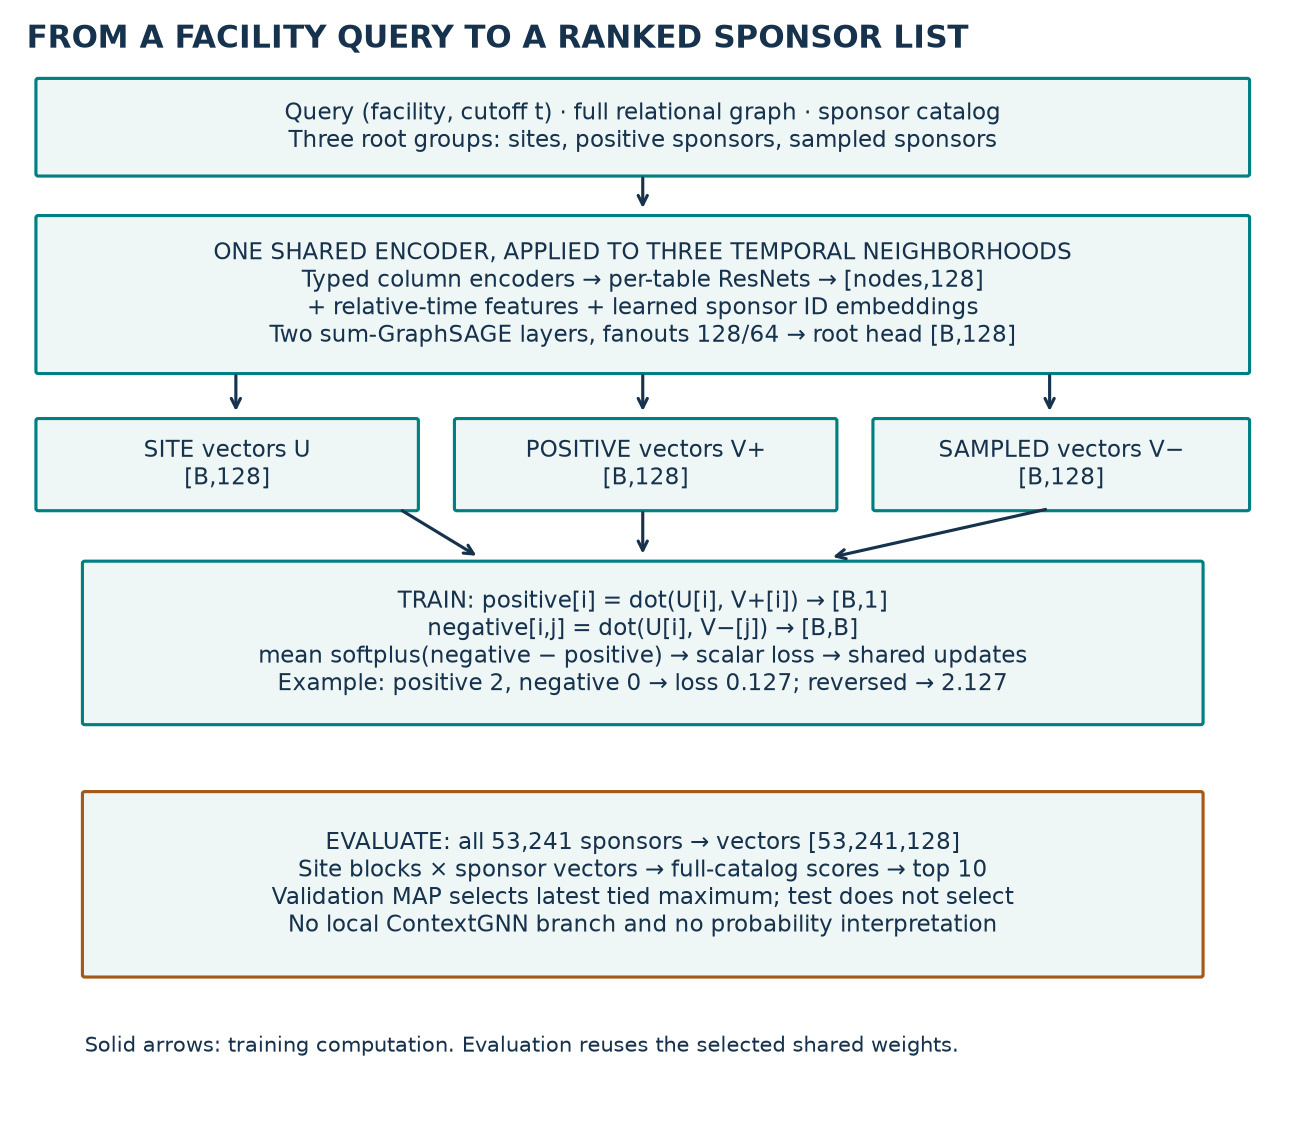<figcaption>Shared temporal row/graph encoder, three training root groups, BPR comparisons and full-catalog inference. Shapes describe actual computation. Scroll horizontally on narrow screens.</figcaption></figure>

**Read the notation.** A **batch** is a group processed together; `B` is its size. An **embedding** is a learned vector, and a **dot product** multiplies corresponding coordinates and adds them: `[1,2] · [3,4] = 11`. A **ResNet** uses shortcut additions between neural layers. A **fanout** limits sampled neighbors at one hop. “Shared weights” means applying the same learned transformation to all three root groups, not fitting three separate encoders.

A batch shares cutoff *t*. Sample one positive sponsor per query and a pool of B uniformly sampled sponsors. Encode the site, positive sponsor and sampled sponsor neighborhoods with the **same model weights**. Each table uses a four-layer, width-128 Frame ResNet before graph propagation. Sponsor rows also receive a learned ID embedding. Scores are dot products: `positive[i] = dot(site[i], positive_sponsor[i])`; `negative[i,j] = dot(site[i], sampled_sponsor[j])`.

**Softplus** is the smooth positive function `log(1 + exp(x))`. **BPR**, Bayesian personalized ranking, names the pairwise objective: penalize a sampled candidate scoring above the positive. Here `i` indexes queries and `j` indexes the shared sampled candidates.

The loss averages `softplus(negative[i,j] − positive[i])` over B×B pairs. If positive score=2 and negative score=0, the contribution is `softplus(-2)≈0.127`; swap the scores and it becomes `≈2.127`. The penalty encourages positives to outrank sampled candidates. It does not calibrate probabilities. With B=512, one batch supplies **262,144 comparisons**, not 512 unrelated binary labels. [Pinned released trainer](https://avistian.github.io/relational/labs/sources/l153/gnn_link.py)

At evaluation, encode all 53,241 sponsors at the split cutoff, score them against each site block, and retain top 10. The manageable B×catalog score blocks are an implementation detail; every catalog item still competes. ContextGNN adds a query-conditioned local scoring branch; this GraphSAGE baseline uses the shared vector/dot-product approach. Its smaller fixed recipe does not reproduce ContextGNN's search or its results.



## 4 · Audit negatives without changing the experiment

“Negative” here means **sampled for the loss**, not proven irrelevant forever. The released loader uses uniform catalog sampling; it does not reject a candidate that belongs to the query's positive set. A shared negative can therefore collide with that query's positive sponsor. Preserve this behavior for the named reproduction and measure collisions separately. [Pinned loader](https://avistian.github.io/relational/labs/sources/l153/loader.py)

<figure class="route-figure" tabindex="0">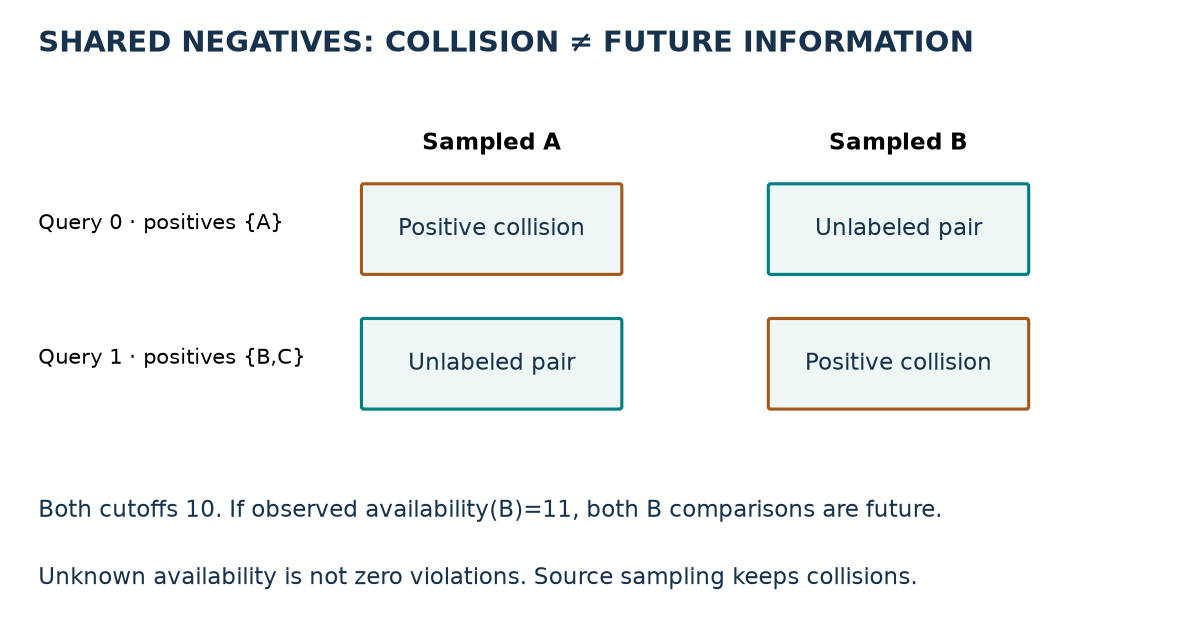<figcaption>A two-query shared pool has two positive collisions. Observed availability can reveal a different pair of violations; missing arrival history stays unknown. Scroll horizontally on narrow screens.</figcaption></figure>

Worked batch: query 0 has positives `{A}`; query 1 has `{B,C}`; both have cutoff 10. Shared candidates `[A,B]` create four comparisons and two positive collisions. If an **observed availability record** says B first became available at 11, two comparisons violate the cutoff. The collision and the availability violation are different counts. A candidate may collide while being perfectly time-legal.

The actual source tables do not establish historical arrival times for every sponsor feature. We can audit sampled dated nodes against their owner cutoff, their original IDs and original edges. We cannot upgrade that check into proof of historical feature availability. Keep that boundary `NOT_OBSERVED` / `NOT_ESTABLISHED`; do not invent availability dates from future outcomes.

**Lab task 1 — `negative_audit`.** Count shared B×B comparisons and positive collisions. Reject mixed-cutoff batches. When an explicit availability vector is supplied, count future comparisons; otherwise return an unknown result. The full runner uses this learner function for its predeclared first-32-batch collision diagnostic; temporal node/edge audits cover all sampled batches.



In [3]:
# TODO: implement the live function used below.
def negative_audit(cutoffs, negative_ids, positives, num_candidates, available_since=None):
    """Audit B×B shared comparisons. Collisions remain source behavior, not proof of leakage."""
    if not cutoffs or len(cutoffs)!=len(positives) or len(negative_ids)!=len(cutoffs):raise ValueError('Aligned nonempty batch required')
    if len(set(cutoffs))!=1:raise ValueError('Shared negatives require a common cutoff')
    if any(not 0<=v<num_candidates for v in negative_ids):raise ValueError('Candidate outside catalog')
    if any(not 0<=v<num_candidates for p in positives for v in p):raise ValueError('Positive outside catalog')
    if available_since is not None and len(available_since)!=num_candidates:raise ValueError('Complete availability vector required')
    collisions=sum(node in set(p) for p in positives for node in negative_ids)
    future=None if available_since is None else sum(available_since[node]>t for t in cutoffs for node in negative_ids)
    return dict(comparisons=len(cutoffs)*len(negative_ids),positive_collisions=collisions,future_comparisons=future,availability='NOT_OBSERVED' if available_since is None else 'OBSERVED')

In [4]:
# CHECK: unchanged behavioral checks.
def rejects(fn):
    try:fn()
    except ValueError:return
    raise AssertionError('Expected invalid evidence to be rejected')
def check_negatives(fn):
    r=fn([10,10],[1,2],[{1},{2,3}],4,[0,0,11,0])
    assert r['comparisons']==4 and r['positive_collisions']==2 and r['future_comparisons']==2
    r=fn([10,10],[1,2],[{1},{2}],4)
    assert r['future_comparisons'] is None and r['availability']=='NOT_OBSERVED'
    rejects(lambda:fn([10,20],[1,2],[{1},{2}],4))
    rejects(lambda:fn([10],[4],[{1}],4))
check_negatives(negative_audit)
print("PASS negative_audit")

PASS negative_audit


## 5 · AP rewards ordering; Hit and Recall answer other questions

> **In plain terms.** Each correct recommendation earns credit for how many recommendations above it are also correct. Placing relevant sponsors earlier earns more credit.

Here `k` is the list length, `r` is a one-based rank, `|R|` counts relevant sponsors, and `1[condition]` equals one when the condition holds and zero otherwise.

For a query with relevant set R and unique ranking L, define `hit_r = 1[L[r]∈R]`. Average precision is:

`AP@k = sum_r=1..k(hit_r × relevant_items_in_top_r / r) / min(k, |R|)`.

MAP is the arithmetic mean of AP across queries. **Hit@k** is 1 if at least one relevant item appears. **Recall@k** divides the retrieved relevant count by the full size of R. We report the macro query averages; a prolific facility does not get extra weight within one query merely because it has more positive sponsors.

<figure class="route-figure" tabindex="0">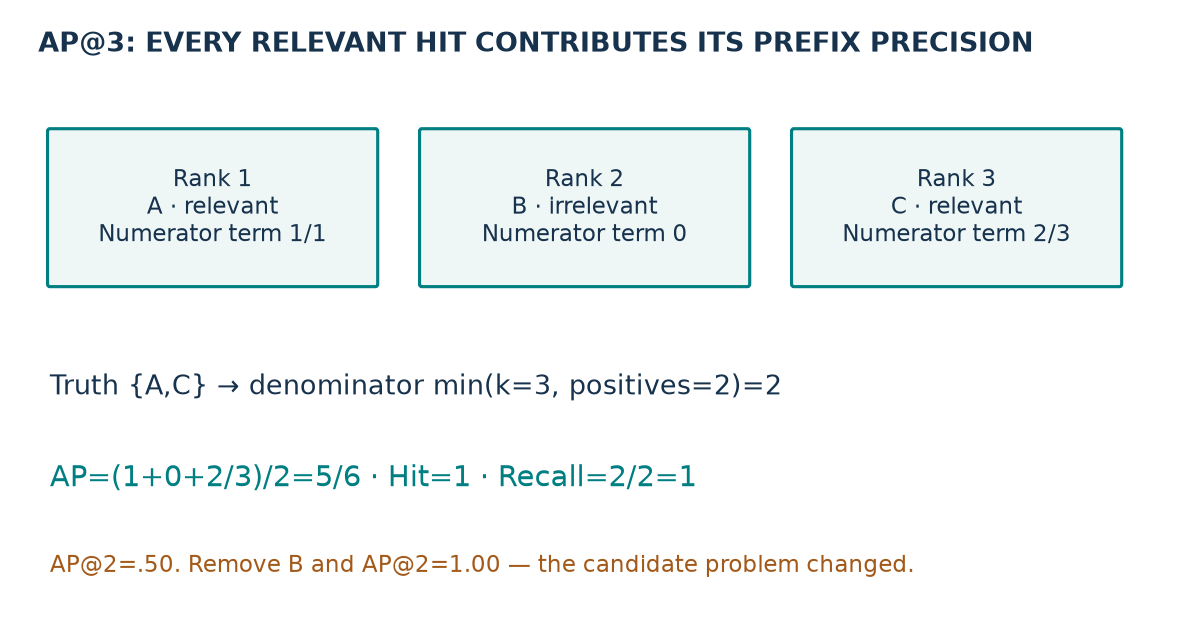<figcaption>AP counts precision at each relevant rank and divides by min(k,positive count). Hit and Recall use different denominators. Scroll horizontally on narrow screens.</figcaption></figure>

With R=`{A,C}` and ranking `[A,B,C,D]`, `AP@3=(1+2/3)/2=5/6`, `Hit@3=1`, and `Recall@3=1`. At k=2, AP and Recall both become 1/2 while Hit remains 1. For a query with 20 relevant sponsors and ten perfect recommendations, AP@10 is 1 but Recall@10 is 1/2. State the denominator. [Released RelBench metric implementation](https://github.com/stanford-star/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/metrics.py)

**Hold the scores fixed.** Let B score .9, A .8, C .7 and D .1, with relevant set `{A,C}` and k=2. Only the allowed candidate set changes:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Allowed set</th><th>Top 2</th><th>AP / Recall / Hit</th></tr></thead><tbody><tr><td>A, B, C, D</td><td>B, A</td><td>.25 / .5 / 1</td></tr><tr><td>A, C, D</td><td>A, C</td><td>1 / 1 / 1</td></tr></tbody></table>

In the full set, only rank 2 contributes: `(1/2)/2=.25`. Removing B moves both relevant items into the list: `(1+1)/2=1`. This is a different candidate protocol, not a learned improvement. Hit cannot distinguish these outcomes. **Try it:** restore B but remove D instead. Predict all three metrics before checking. **Check:** the top two remain B,A, so all three metrics retain their full-set values.

Predict: remove B from ranking A,B,C,D with truth A,C. What changes in AP@2?
Worked intervention: full ranking A,B,C,D at k2 has AP.50; remove B and AP becomes1.00. Candidate protocol changed.

**Lab task 2 — `ranking_metrics`.** Align by complete query keys, reject missing/duplicate queries and duplicate or out-of-catalog recommendations, then compute MAP, Hit and Recall. CHECK includes one entity at two timestamps and more positives than k. This is not the classification average-precision metric applied to a pooled list of all query–item pairs.



In [5]:
# TODO: implement the live function used below.
def ranking_metrics(truth, predictions, k, num_candidates):
    """Macro query MAP, Hit and Recall; AP divides by min(k, |positives|)."""
    if not 0<k<=num_candidates or not truth:raise ValueError('Nonempty population and valid k required')
    def index(rows):
        out={}
        for row in rows:
            key=(int(row['entity']),int(row['time']))
            if key in out:raise ValueError('Duplicate query key')
            out[key]=row
        return out
    labels=index(truth);rankings=index(predictions)
    if labels.keys()!=rankings.keys():raise ValueError('Exact query-key coverage required')
    aps=[];hits=[];recalls=[]
    for key,row in labels.items():
        positives=set(row['positives']);ranked=list(rankings[key]['ranking'])
        if not positives or len(ranked)!=k or len(set(ranked))!=k:raise ValueError('Nonempty truth and k distinct recommendations required')
        if any(not isinstance(v,int) or not 0<=v<num_candidates for v in positives|set(ranked)):raise ValueError('Invalid candidate ID')
        count=0;terms=[]
        for rank,node in enumerate(ranked,1):
            if node in positives:count+=1;terms.append(count/rank)
        aps.append(math.fsum(terms)/min(k,len(positives)));hits.append(float(count>0));recalls.append(count/len(positives))
    return dict(n=len(aps),map=math.fsum(aps)/len(aps),hit=math.fsum(hits)/len(hits),recall=math.fsum(recalls)/len(recalls))

In [6]:
# CHECK: unchanged behavioral checks.
def rejects(fn):
    try:fn()
    except ValueError:return
    raise AssertionError('Expected invalid evidence to be rejected')
def check_ranking(fn):
    truth=[{'entity':1,'time':10,'positives':[1,3,4]}, {'entity':1,'time':20,'positives':[2]}]
    pred=[{'entity':1,'time':20,'ranking':[0,2]}, {'entity':1,'time':10,'ranking':[1,3]}]
    r=fn(truth,pred,2,5)
    assert math.isclose(r['map'],.75) and r['hit']==1 and math.isclose(r['recall'],5/6)
    assert r['n']==2
    rejects(lambda:fn(truth,pred[:1],2,5))
    bad=copy.deepcopy(pred);bad[0]['ranking']=[2,2];rejects(lambda:fn(truth,bad,2,5))
    bad=copy.deepcopy(pred);bad[0]['time']=10;rejects(lambda:fn(truth,bad,2,5))
    bad=copy.deepcopy(pred);bad[0]['ranking']=[2,5];rejects(lambda:fn(truth,bad,2,5))
    bad=copy.deepcopy(truth);bad[0]['positives']=[];rejects(lambda:fn(bad,pred,2,5))
check_ranking(ranking_metrics)
print("PASS ranking_metrics")

PASS ranking_metrics


## 6 · Reproduce a named result, then state what happened

**Named target:** RelBench v1 Table 8, GraphSAGE, `rel-trial/site-sponsor-run`: test **10.70 ± 1.10% MAP@10**, validation **14.09 ± 0.77%**, five runs. The frozen descriptive mean tolerance is ±2 percentage points; it is not an equivalence test. [Primary reading: Table 8 and Appendix B.2](https://arxiv.org/html/2407.20060v1#A2.T8)

**Fixed protocol:** seeds 0–4; full archive population; 20 epochs; two sum-GraphSAGE layers; width 128; uniform fanouts 128/64; batch 512; Adam .001; shared-negative BPR; shallow sponsor embeddings. The release drops incomplete timestamp batches and stops after at most **2001** batches per epoch. “Full reproduction” preserves this released schedule rather than promising every training row is used each epoch. The latest tied validation maximum selects the checkpoint. Final validation resamples neighborhoods, so its score can differ from the selection score. [Full source and deviation ledger](https://avistian.github.io/relational/labs/l153-reproduction.md)

**Full selected reproduction: INCOMPLETE — budget gate STOP.** The full code is provided, but no five-seed test comparison is claimed.

The fresh pilot trained **32 batches / 16,384 query occurrences**, then evaluated all **37,003 validation queries** against the full **53,241-candidate catalog**. Its validation MAP@10 was **1.051%**, Hit@10 **7.040%**, Recall@10 **5.648%**. These are partial-training diagnostics, not final baseline results. Test was not evaluated.

Training the 32 pilot batches took **38.2s**; a full validation pass took **20.1s**. The released timestamp sampler yields **1,299 full batches** per epoch, covering **665,088 query occurrences**. The remaining timestamp-group tails are dropped by source design.

A linear scenario for five 20-epoch runs projects **USD41.23 compute before overhead**. The projection includes the pilot's audit/cold-start cost; it is not a mathematical lower bound. The safety-adjusted forecast exceeds the remaining allowance, so no full fits were dispatched. We preserved the recipe rather than reducing epochs, candidates or seeds. [Recorded cost decision](https://avistian.github.io/relational/labs/evidence/l153/cost-decision.json).

<figure class="route-figure" tabindex="0">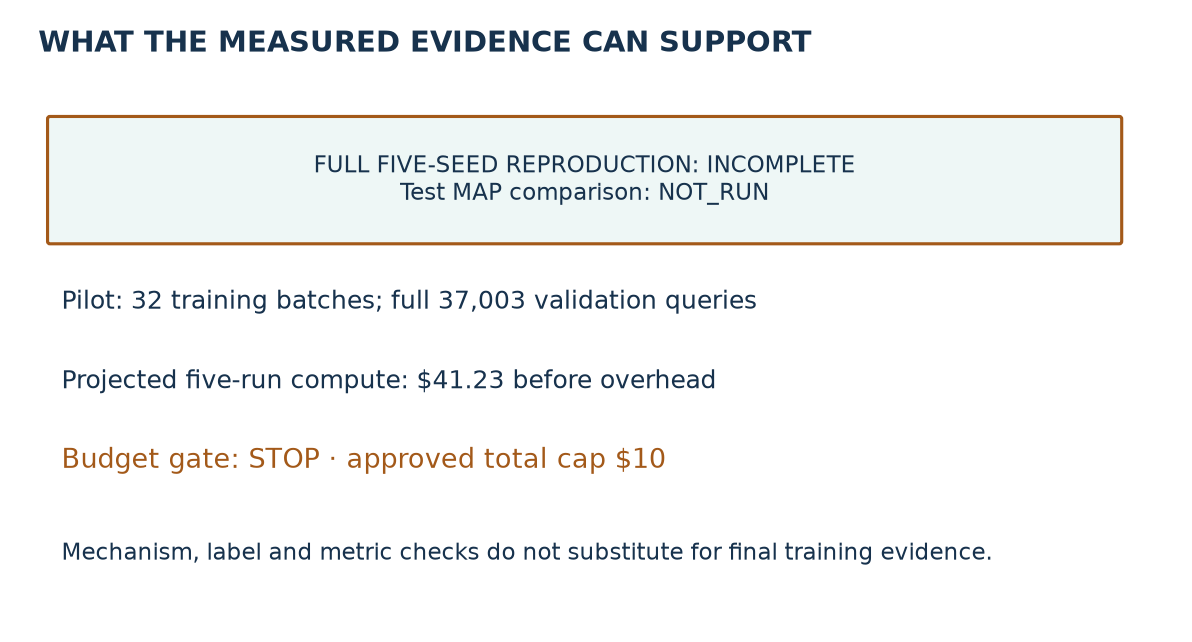<figcaption>Measured execution scope and the cost gate. A pilot validation score cannot replace five completed test runs. Scroll horizontally on narrow screens.</figcaption></figure>
**What passed:** all **733,741 query labels** were independently reconstructed through interval/join logic in addition to the source-SQL check. All **37,003 saved rankings** were independently aligned and rescored. The pilot audited **229,640 root occurrences**, **4,503,923 dated-node occurrences** and **6,783,360 sampled-edge occurrences**, with zero observed owner-cutoff violations.

The first32training batches contained **356 positive collisions out of 8,388,608 shared comparisons**. This diagnostic preserves source sampling; it does not establish a false-negative rate for unobserved relevance. Candidate/feature arrival history remains unobserved.

The first real backward pass contained **384 nonfinite gradient entries**. Source behavior was retained and recorded. Finite prediction parity with the released model (maximum absolute difference **2.38e-07**) and the healthy synthetic mechanism check do not certify healthy optimization on this real dataset.

Current immutable resource reservations plus the USD3 overhead allowance total **USD4.253952** under the USD10 cap. Recorded main-worker body estimate: **USD0.285716**; this excludes unitemized overhead and is not an invoice. [Budget](https://avistian.github.io/relational/labs/_budget_l153.json) · [Evidence](https://avistian.github.io/relational/labs/evidence/l153/summary.json).

The archived default notebook passed in an isolated pinned runtime. After correcting only the inclusive score-tolerance boundary and its check, all revised default cells passed locally on CPU. The original module and notebook hashes are retained for the pinned execution; the source model and trainer are unchanged. The full training gate remains NOT_RUN; live Colab remains NOT_CHECKED.


**Lab task 3 — `portfolio_entry`.** Accept a paper comparison only after verifying five complete seeds, one protocol hash, full validation/test coverage, valid scores and zero observed temporal violations. Incomplete runs must fail this completion check. The lab can still export an honest partial entry carrying the measured evidence and remaining work. A passing author notebook does not establish learner mastery or a completed benchmark.



In [7]:
# TODO: implement the live function used below.
def portfolio_entry(records, protocol_hash, expected_counts):
    """Reject incomplete/mixed evidence before comparing the five-run mean with Table8."""
    if len(records)!=5 or sorted(r['seed'] for r in records)!=list(range(5)):raise ValueError('Exactly seeds0–4 required')
    for r in records:
        if r['status']!='COMPLETE' or r['protocol_hash']!=protocol_hash or r['counts']!=expected_counts or r['temporal_violations']!=0:raise ValueError('Incomplete, mixed or temporally invalid evidence')
        if any(not math.isfinite(r['scores'][s]) or not 0<=r['scores'][s]<=1 for s in ['val','test']):raise ValueError('Invalid MAP')
    out={s:dict(mean=statistics.mean(r['scores'][s] for r in records),sample_sd=statistics.stdev(r['scores'][s] for r in records)) for s in ['val','test']}
    out.update(status='COMPLETE',paper_target=.107,tolerance=.02,paper_comparison='CLOSE' if abs(out['test']['mean']-.107)<=.02+8*math.ulp(.107) else 'OUTSIDE_TOLERANCE',historical_identity='NOT_ESTABLISHED',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
    return out

In [8]:
# CHECK: unchanged behavioral checks.
def rejects(fn):
    try:fn()
    except ValueError:return
    raise AssertionError('Expected invalid evidence to be rejected')
def check_portfolio(fn):
    records=[dict(seed=i,status='COMPLETE',protocol_hash='p',counts={'val':2,'test':3},scores={'val':.2,'test':.107},temporal_violations=0) for i in range(5)]
    r=fn(records,'p',{'val':2,'test':3});assert r['paper_comparison']=='CLOSE' and r['test']['sample_sd']==0
    for boundary in (.107-.02,.107+.02):
        edge=[dict(r,scores={'val':.2,'test':boundary}) for r in records]
        assert fn(edge,'p',{'val':2,'test':3})['paper_comparison']=='CLOSE', 'Inclusive tolerance boundary'
    for outside in (.107-.02-1e-9,.107+.02+1e-9):
        edge=[dict(r,scores={'val':.2,'test':outside}) for r in records]
        assert fn(edge,'p',{'val':2,'test':3})['paper_comparison']=='OUTSIDE_TOLERANCE'
    rejects(lambda:fn(records[:4],'p',{'val':2,'test':3}))
    for field,value in [('seed',1),('status','PARTIAL_TIMING_PILOT'),('protocol_hash','q'),('temporal_violations',1),('counts',{'val':1,'test':3})]:
        bad=copy.deepcopy(records);bad[0][field]=value;rejects(lambda:fn(bad,'p',{'val':2,'test':3}))
check_portfolio(portfolio_entry)
print("PASS portfolio_entry")

PASS portfolio_entry


In [9]:
# CHECK: all saved rankings are rescored using your live metric function.
truth={s:json.loads(gzip.decompress(base64.b64decode(v))) for s,v in TRUTH_PACKET.items()}
count=0;measured={};fresh_records=[]
for name,item in PAYLOAD.items():
 raw=base64.b64decode(item['data']);assert hashlib.sha256(raw).hexdigest()==item['sha256'];z=np.load(io.BytesIO(raw));measured[name]={}
 for split in ['val','test']:
  if split+'_pred' not in z:continue
  ranked=[dict(entity=int(e),time=int(t),ranking=list(map(int,row))) for e,t,row in zip(z[split+'_entity'],z[split+'_time'],z[split+'_pred'])]
  scores=ranking_metrics(truth[split],list(reversed(ranked)),10,53241);measured[name][split]=scores;count+=scores['n']
  expected=AUTHOR_SUMMARY['independent_metrics'][name][split]
  for key in ['map','hit','recall']:assert abs(scores[key]-expected[key])<1e-12
 if name.startswith('seed-'):
  record=next(r for r in AUTHOR_SUMMARY['records'] if r['seed']==int(name.split('-')[1]));fresh_records.append(dict(record,scores={s:v['map'] for s,v in measured[name].items()}))
protocol_hash=hashlib.sha256(SOURCE_FILES['sources/l153/protocol.json'].encode()).hexdigest()
if len(fresh_records)==5:
 verdict=portfolio_entry(fresh_records,protocol_hash,{'val':37003,'test':27428})
else:
 try:portfolio_entry(fresh_records,protocol_hash,{'val':37003,'test':27428})
 except ValueError:pass
 else:raise AssertionError('Incomplete evidence accepted')
 verdict=dict(status='INCOMPLETE',paper_comparison='NOT_RUN',reason='Measured cost gate blocks five full fits')
entry=dict(evidence_owner='AUTHOR_PACKET_INDEPENDENTLY_RESCORED',task='rel-trial/site-sponsor-run',metrics=measured,verdict=verdict,protocol_hash=protocol_hash,cost_decision=COST_DECISION,written_defense=None,learner='PENDING_WRITTEN_DEFENSE')
Path('l153-portfolio-entry.json').write_text(json.dumps(entry,indent=2));display(pd.DataFrame({k:v['val'] for k,v in measured.items()}).T)
print('AUTHOR_PACKET_INDEPENDENTLY_RESCORED',count,'rankings;',verdict)


,n,map,hit,recall
pilot,37003.0,0.010508,0.0704,0.056483


AUTHOR_PACKET_INDEPENDENTLY_RESCORED 37003 rankings; {'status': 'INCOMPLETE', 'paper_comparison': 'NOT_RUN', 'reason': 'Measured cost gate blocks five full fits'}


## 7 · Export entry 3 and defend the boundary

Open the [student notebook](https://avistian.github.io/relational/labs/0153-recommendation-portfolio.ipynb), [rendered solution](https://avistian.github.io/relational/labs/html/0153-recommendation-portfolio.html), [reference card](https://avistian.github.io/relational/reference/recommendation-portfolio.html) and [entry template](https://avistian.github.io/relational/labs/l153-entry-template.md). The default notebook independently rescores the embedded author evidence. Its post-EXIT appendix contains the complete visible model, loader, graph construction and trainer, with a separate pinned GPU gate for fresh execution.

**EXIT:** implement all three live functions, pass their checks, export `l153-portfolio-entry.json`, and submit 250–400 words defending the query population, candidate population, metric denominator, temporal/negative distinction and measured reproduction status. Grade each of those five dimensions 0–2; readiness requires at least 8/10 with no zero. A pilot-only entry must say what prevents a final comparison. It does not satisfy the portfolio's completed-baseline requirement.

Write your defense before reviewing the model answer; send it to the teaching agent.

Tomorrow, reconstruct AP for `[A,B,C]` without notes. In a week, explain why removing an irrelevant candidate can improve MAP without changing the model. L154 will combine the three entries while retaining task units and evidence gaps; do not average MAE and MAP together or mark all three reproductions complete automatically.

Ask the teaching agent about any unclear step, or send your EXIT entry and written defense for review. Author preparation is not learner completion. Live Colab and deployment remain `NOT_CHECKED` unless separately verified.


## Post-EXIT · Complete implementation and fresh-run appendix

Read the shared encoders, GraphSAGE and output head below. These are the exact classes passed to the full runner and exercised by the synthetic output/gradient check. The loader and graph-building source are supplied visibly as released primitives; installed versions must match their pinned bytes before training. The visible trainer string is written to the source file that the instrumented runner actually executes. Its mathematical training/selection behavior is preserved.

`RUN_FULL_REPRODUCTION=False` by default. Full manual execution is longer than a teaching notebook and has no monetary meter. The managed Modal operator reserves each allocation and blocks dispatch when the full forecast exceedsUSD10. Historical reconstruction gaps remain even after a full fresh run. Install using `labs/requirements-l117-runtime.txt` plus torch2.5.1 CUDA12.4 and pyg-lib0.4.0+pt25cu124; the complete reproducible image recipe is in `modal/l153_repro.py`.

In [10]:
# PROVIDED: Released encoder and model classes
"""Visible unmodified released encoder, temporal encoder, GraphSAGE and model; MIT."""
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# PROVIDED: Independent source-label reconstruction
"""Independent interval/join reconstruction; no call to task.make_table."""
import json
from pathlib import Path
import pandas as pd

def independent_labels(output):
 from relbench.datasets import get_dataset
 from relbench.tasks import get_task
 ds=get_dataset('rel-trial');task=get_task('rel-trial','site-sponsor-run');db=ds.get_db(upto_test_timestamp=False)
 fs=db.table_dict['facilities_studies'].df;ss=db.table_dict['sponsors_studies'].df
 # Many facilities can belong to a study; group sponsor sets before traversing links.
 sponsor_sets=ss.groupby('nct_id')['sponsor_id'].agg(lambda x:set(int(v) for v in x.dropna() if int(v)<task.num_dst_nodes)).to_dict()
 result={}
 for split in ['train','val','test']:
  table=task.get_table(split,mask_input_cols=False).df;count=0
  for cutoff,group in table.groupby(task.time_col):
   active=fs[(fs.date>cutoff)&(fs.date<=cutoff+pd.Timedelta(days=365))];expected={}
   for site,study in active[['facility_id','nct_id']].itertuples(index=False,name=None):
    if pd.isna(site) or int(site)>=task.num_src_nodes:continue
    values=sponsor_sets.get(study,set())
    if values:expected.setdefault(int(site),set()).update(values)
   observed={int(site):set(map(int,targets)) for site,targets in group[[task.src_entity_col,task.dst_entity_col]].itertuples(index=False,name=None)}
   assert expected==observed,(split,str(cutoff),'independent labels mismatch');count+=len(group)
  result[split]=count
 report={'status':'PASS','independently_rebuilt_queries':result,'interval':'(cutoff,cutoff+365days]','join':'facility-study dates; sponsor-study nct_id; no sponsor date filter'}
 Path(output).write_text(json.dumps(report,indent=2));return report


In [12]:
# PROVIDED: Fresh graph and task preparation
"""Fresh full-data graph and independent source/label audits."""
import json,hashlib
from pathlib import Path
import torch
def sha(path):
 h=hashlib.sha256()
 with Path(path).open('rb') as f:
  while block:=f.read(8*1024*1024):h.update(block)
 return h.hexdigest()

def prepare(root,source):
 from relbench.datasets import get_dataset
 from relbench.tasks import get_task
 from relbench.modeling.utils import get_stype_proposal
 from relbench.modeling.graph import make_pkey_fkey_graph
 from torch_frame.config import TextEmbedderConfig
 from sentence_transformers import SentenceTransformer
 from torch_geometric.seed import seed_everything
 root=Path(root);root.mkdir(parents=True,exist_ok=True);seed_everything(42)
 dataset=get_dataset('rel-trial',download=True);task=get_task('rel-trial','site-sponsor-run',download=True)
 archive_hashes={}
 for name,expected in [('db.zip','9fb5ba14f7cbca8115f3dfe0800415f98d6ddc15561e56c35ee614da6b89552a'),('tasks/site-sponsor-run.zip','64c8b039b81d45b708e85c71c319e95372dd8f9a832e4255aad448ca0fe0a879')]:
  path=Path(dataset.cache_dir)/name;actual=sha(path);assert actual==expected,(name,actual);archive_hashes[name]=actual
 db=dataset.get_db();types=get_stype_proposal(db)
 tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
 counts={s:len(t) for s,t in tables.items()};print('COUNTS',counts,flush=True)
 # Reconstruct source SQL on the full database before any training.
 import pandas as pd
 rebuilt={};full_db=dataset.get_db(upto_test_timestamp=False)
 for split,table in tables.items():
  check=task.filter_dangling_entities(task.make_table(full_db,pd.DatetimeIndex(sorted(table.df[task.time_col].unique()))))
  def keyed(t):return {(int(row[task.src_entity_col]),int(pd.Timestamp(row[task.time_col]).value)):sorted(map(int,row[task.dst_entity_col])) for _,row in t.df.iterrows()}
  assert keyed(check)==keyed(table),'Raw SQL label mismatch'
  rebuilt[split]=len(check)
 (root/'label-audit.json').write_text(json.dumps({'status':'PASS','source_SQL_reconstructed':rebuilt,'independent_algorithm':'NOT_CHECKED'},indent=2))
 text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cuda' if torch.cuda.is_available() else 'cpu')
 def embed(strings):return torch.from_numpy(text.encode(strings,show_progress_bar=False))
 data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
 torch.save((data,stats),root/'graph.pt')
 meta={'graph_sha256':sha(root/'graph.pt'),'counts':counts,'rows':{k:len(t) for k,t in db.table_dict.items()},'eval_k':task.eval_k,'num_dst_nodes':task.num_dst_nodes,'src':task.src_entity_table,'dst':task.dst_entity_table,'stypes':types,'database_files':{str(p.relative_to(Path(dataset.cache_dir))):sha(p) for p in Path(dataset.cache_dir).rglob('*.parquet')},'task_files':{p.name:sha(p) for p in Path(task.cache_dir).rglob('*.parquet')}}
 meta['archive_hashes']=archive_hashes
 (root/'stypes.json').write_text(json.dumps(types,default=str))
 independent_labels(root/'independent-labels.json')
 import gzip,pandas as pd
 for split,table in tables.items():
  table.df.to_parquet(root/(split+'.parquet'))
  if split!='train':
   rows=[dict(entity=int(e),time=int(pd.Timestamp(t).value),positives=list(map(int,v))) for e,t,v in table.df[[task.src_entity_col,task.time_col,task.dst_entity_col]].itertuples(index=False,name=None)]
   with gzip.open(root/(split+'-truth.json.gz'),'wt') as f:json.dump(rows,f)
 (root/'prepared.json').write_text(json.dumps(meta,indent=2,default=str));return meta


In [13]:
# PROVIDED: Every sampled occurrence audit
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


In [14]:
# PROVIDED: full visible released source; this text is supplied to the runner.
RELEASED_GRAPH = r'''import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )


class LinkTrainTableInput(NamedTuple):
    r"""Training table input for link prediction.

    - src_nodes is a Tensor of source node indices.
    - dst_nodes is PyTorch sparse tensor in csr format.
        dst_nodes[src_node_idx] gives a tensor of destination node
        indices for src_node_idx.
    - num_dst_nodes is the total number of destination nodes.
        (used to perform negative sampling).
    - src_time is a Tensor of time for src_nodes
    """

    src_nodes: Tuple[NodeType, Tensor]
    dst_nodes: Tuple[NodeType, Tensor]
    num_dst_nodes: int
    src_time: Optional[Tensor]


def get_link_train_table_input(
    table: Table,
    task: RecommendationTask,
) -> LinkTrainTableInput:
    r"""Get the training table input for link prediction."""

    src_node_idx: Tensor = torch.from_numpy(
        table.df[task.src_entity_col].astype(int).values
    )
    exploded = table.df[task.dst_entity_col].explode()
    coo_indices = torch.from_numpy(
        np.stack([exploded.index.values, exploded.values.astype(int)])
    )
    sparse_coo = torch.sparse_coo_tensor(
        coo_indices,
        torch.ones(coo_indices.size(1), dtype=bool),
        (len(src_node_idx), task.num_dst_nodes),
    )
    dst_node_indices = sparse_coo.to_sparse_csr()

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    return LinkTrainTableInput(
        src_nodes=(task.src_entity_table, src_node_idx),
        dst_nodes=(task.dst_entity_table, dst_node_indices),
        num_dst_nodes=task.num_dst_nodes,
        src_time=time,
    )
'''
_ = (P/"sources/l153/graph.py").write_text(RELEASED_GRAPH)

In [15]:
# PROVIDED: full visible released source; this text is supplied to the runner.
RELEASED_LOADER = r'''import random
from typing import Dict, Iterator, List, Optional, Tuple, Union

import torch
from torch import Tensor
from torch.utils.data import DataLoader, Dataset, Sampler
from torch_geometric.data import Data, FeatureStore, GraphStore, HeteroData
from torch_geometric.loader import NodeLoader
from torch_geometric.sampler import NeighborSampler, NodeSamplerInput
from torch_geometric.sampler.base import SubgraphType
from torch_geometric.typing import EdgeType, NodeType, OptTensor


def batched_arange(count: Tensor) -> Tuple[Tensor, Tensor]:
    r"""Fast implementation of bached version of torch.arange. It essentially does the
    following >>> batch = torch.cat([torch.full((c,), i) for i, c in enumerate(count)])
    >>> arange = torch.cat([torch.arange(c) for c in count])

    Args:
        count (Tensor): The count vectors.

    Returns:
        batch (Tensor): batch[i] indicates the batch index of
            batched_arange[i]
        arange (Tensor): batched version of arange
    """
    ptr = count.new_zeros(count.numel() + 1)
    torch.cumsum(count, dim=0, out=ptr[1:])

    batch = torch.arange(count.numel(), device=count.device).repeat_interleave(
        count, output_size=ptr[-1]
    )  # type: ignore

    arange = torch.arange(batch.numel(), device=count.device)
    arange -= ptr[batch]

    return batch, arange


class SparseTensor:
    r"""Sparse CSR tensor object that allows fast row tensor indexing."""

    def __init__(
        self,
        sparse_tensor: Tensor,
        device: Optional[Union[str, torch.device]] = None,
    ):
        assert sparse_tensor.layout == torch.sparse_csr
        self._size = sparse_tensor.size()
        self._crow_indices = sparse_tensor.crow_indices().to(device)
        self._col_indices = sparse_tensor.col_indices().to(device)

    def __getitem__(self, indices: Tensor) -> Tuple[Tensor, Tensor]:
        r"""Given a tensor of row indices, return a tuple of tensors.

        - :obj:`row_batch` (Tensor): Batch offset for column indices.
        - :obj:`col_index` (Tensor): Column indices.
        Specifically, :obj:`sparse_tensor[indices[i]]` can be obtained by
        :obj:`col_index[row_batch == i]`.
        """
        if not (indices < self.size()[0]).all():
            raise IndexError(
                f"The index {indices.max()} is out-of-range. Needs to be smaller "
                f"than {{self.size()[0]}}."
            )
        count = self._crow_indices[indices + 1] - self._crow_indices[indices]
        row_batch, arange = batched_arange(count)
        col_index = self._col_indices[arange + self._crow_indices[indices][row_batch]]
        return row_batch, col_index

    def size(self) -> torch.Size:
        return self._size


class CustomNodeLoader(NodeLoader):

    def get_neighbors(
        self,
        input_data: NodeSamplerInput,
    ) -> Union[Data, HeteroData]:
        r"""Samples a subgraph from a batch of input nodes."""
        out = self.node_sampler.sample_from_nodes(input_data)
        out = self.filter_fn(out)
        return out


class TimestampSampler(Sampler[int]):
    r"""A TimestampSampler that samples rows from the same timestamp."""

    def __init__(
        self,
        timestamp: Tensor,
        batch_size: int,
    ):
        super().__init__()
        self.batch_size = batch_size
        self.time_dict = {
            int(time): (timestamp == time).nonzero().view(-1)
            for time in timestamp.unique()
        }
        self.num_batches = sum(
            [indices.numel() // batch_size for indices in self.time_dict.values()]
        )

    def __iter__(self) -> Iterator[List[int]]:
        all_batches = []
        for indices in self.time_dict.values():
            # Random shuffle values:
            indices = indices[torch.randperm(indices.numel())]
            batches = torch.split(indices, self.batch_size)
            for batch in batches:
                if len(batch) < self.batch_size:
                    continue
                else:
                    all_batches.append(batch.tolist())

        random.shuffle(all_batches)

        for batch in all_batches:
            yield batch

    def __len__(self) -> int:
        return self.num_batches


class CustomLinkDataset(Dataset):
    r"""A custom link prediction dataset.

    Sample source nodes, time, and one positive destination node.
    """

    def __init__(
        self,
        src_node_indices: Tensor,
        dst_node_indices: Tensor,  # CSR sparse matrix
        num_dst_nodes: int,
        src_time: Tensor,
    ):
        assert len(src_node_indices) == len(dst_node_indices) and len(
            src_node_indices
        ) == len(src_time)
        self.src_node_indices = src_node_indices
        self.dst_node_indices = dst_node_indices
        self.num_dst_nodes = num_dst_nodes
        self.src_time = src_time

    def __getitem__(self, index) -> Tensor:
        r"""Returns 1-dim tensor of size 3.

        - source node index
        - positive destination node index
        - source node time
        """
        return torch.tensor(
            [
                self.src_node_indices[index],
                random.choice(self.dst_node_indices[index].indices()[0]),
                self.src_time[index],
            ]
        )

    def __len__(self):
        return len(self.src_node_indices)


class LinkNeighborLoader(DataLoader):
    r"""A custom neighbor loader for link prediction.
    Based on https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/loader/neighbor_loader.html

    Args:
        src_nodes (Tuple[NodeType, Tensor]): A tensor of source node indices.
        dst_nodes (Tuple[NodeType, Tensor]): A csr sparse tensor, where
            dst_nodes[index] is a list of destination node indices
            for src_nodes[index] at src_time[index].
        num_dst_nodes (int): Total number of destination nodes. Used to
            determine the range of negative samples.
        src_time (torch.Tensor, optional): Optional values to override the
            timestamp for the input nodes given in :obj:`input_nodes`. If not
            set, will use the timestamps in :obj:`time_attr` as default (if
            present). The :obj:`time_attr` needs to be set for this to work.
            (default: :obj:`None`)
        share_same_time (bool): Whether to share the seed time within mini-batch
            or not (default: :obj:`False`)
    """

    def __init__(
        self,
        data: Union[Data, HeteroData, Tuple[FeatureStore, GraphStore]],
        num_neighbors: Union[List[int], Dict[EdgeType, List[int]]],
        src_nodes: Tuple[NodeType, Tensor],
        dst_nodes: Tuple[NodeType, Tensor],
        num_dst_nodes: int,
        src_time: OptTensor = None,
        share_same_time: bool = False,
        subgraph_type: Union[SubgraphType, str] = "directional",
        temporal_strategy: str = "uniform",
        time_attr: Optional[str] = None,
        **kwargs,
    ):
        node_sampler = NeighborSampler(
            data,
            num_neighbors=num_neighbors,
            subgraph_type=subgraph_type,
            disjoint=True,
            temporal_strategy=temporal_strategy,
            time_attr=time_attr,
            share_memory=kwargs.get("num_workers", 0) > 0,
        )

        self.data = data
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        self.num_dst_nodes = num_dst_nodes
        self.src_time = src_time
        self.share_same_time = share_same_time

        kwargs.pop("dataset", None)
        kwargs.pop("collate_fn", None)
        if share_same_time:
            kwargs.pop("sampler", None)
            kwargs["batch_sampler"] = TimestampSampler(
                src_time,
                kwargs["batch_size"],
            )
            kwargs.pop("batch_size", None)

        dataset = CustomLinkDataset(
            self.src_nodes[1],
            dst_nodes[1],
            num_dst_nodes,
            src_time,
        )

        self.src_node_type = self.src_nodes[0]
        self.dst_node_type = self.dst_nodes[0]
        self.src_loader = CustomNodeLoader(
            data,
            node_sampler,
            src_nodes[0],
        )
        self.dst_loader = CustomNodeLoader(
            data,
            node_sampler,
            dst_nodes[0],
        )

        super().__init__(dataset, collate_fn=self.collate_fn, **kwargs)

    def collate_fn(
        self,
        index: Tensor,
    ) -> Tuple[HeteroData, HeteroData, HeteroData]:
        r"""Samples a subgraph from a batch of input nodes."""
        index = torch.stack(index)
        src_indices = index[:, 0].contiguous()
        pos_dst_indices = index[:, 1].contiguous()
        time = index[:, 2].contiguous()
        neg_dst_indices = torch.randint(0, self.num_dst_nodes, size=(len(src_indices),))
        src_out = self.src_loader.get_neighbors(
            NodeSamplerInput(
                input_id=src_indices,
                node=src_indices,
                time=time,
                input_type=self.src_node_type,
            )
        )

        pos_dst_out = self.dst_loader.get_neighbors(
            NodeSamplerInput(
                input_id=pos_dst_indices,
                node=pos_dst_indices,
                time=time,
                input_type=self.dst_node_type,
            )
        )

        neg_dst_out = self.dst_loader.get_neighbors(
            NodeSamplerInput(
                input_id=neg_dst_indices,
                node=neg_dst_indices,
                time=time,
                input_type=self.dst_node_type,
            )
        )

        return src_out, pos_dst_out, neg_dst_out
'''
_ = (P/"sources/l153/loader.py").write_text(RELEASED_LOADER)

In [16]:
# PROVIDED: full visible released source; this text is supplied to the runner.
RELEASED_TRAINER = r'''import argparse
import copy
import json
import os
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from model import Model
from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from tqdm import tqdm

from relbench.base import Dataset, RecommendationTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph
from relbench.modeling.loader import LinkNeighborLoader
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="rel-hm")
parser.add_argument("--task", type=str, default="user-item-purchase")
parser.add_argument("--lr", type=float, default=0.001)
parser.add_argument("--epochs", type=int, default=20)
parser.add_argument("--eval_epochs_interval", type=int, default=1)
parser.add_argument("--batch_size", type=int, default=512)
parser.add_argument("--channels", type=int, default=128)
parser.add_argument("--aggr", type=str, default="sum")
parser.add_argument("--num_layers", type=int, default=2)
parser.add_argument("--num_neighbors", type=int, default=128)
parser.add_argument("--temporal_strategy", type=str, default="uniform")
# Use the same seed time across the mini-batch and share the negatives
parser.add_argument("--share_same_time", action="store_true", default=True)
parser.add_argument(
    "--no-share_same_time", dest="share_same_time", action="store_false"
)
# Whether to use shallow embedding on dst nodes or not.
parser.add_argument("--use_shallow", action="store_true", default=True)
parser.add_argument("--no-use_shallow", dest="use_shallow", action="store_false")
parser.add_argument("--max_steps_per_epoch", type=int, default=2000)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
    "--cache_dir",
    type=str,
    default=os.path.expanduser("~/.cache/relbench_examples"),
)
args = parser.parse_args()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_num_threads(1)
seed_everything(args.seed)

dataset: Dataset = get_dataset(args.dataset, download=True)
task: RecommendationTask = get_task(args.dataset, args.task, download=True)
tune_metric = "link_prediction_map"
assert task.task_type == TaskType.LINK_PREDICTION

stypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")
try:
    with open(stypes_cache_path, "r") as f:
        col_to_stype_dict = json.load(f)
    for table, col_to_stype in col_to_stype_dict.items():
        for col, stype_str in col_to_stype.items():
            col_to_stype[col] = stype(stype_str)
except FileNotFoundError:
    col_to_stype_dict = get_stype_proposal(dataset.get_db())
    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)
    with open(stypes_cache_path, "w") as f:
        json.dump(col_to_stype_dict, f, indent=2, default=str)

data, col_stats_dict = make_pkey_fkey_graph(
    dataset.get_db(),
    col_to_stype_dict=col_to_stype_dict,
    text_embedder_cfg=TextEmbedderConfig(
        text_embedder=GloveTextEmbedding(device=device), batch_size=256
    ),
    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",
)

num_neighbors = [int(args.num_neighbors // 2**i) for i in range(args.num_layers)]

train_table_input = get_link_train_table_input(task.get_table("train"), task)
train_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=num_neighbors,
    time_attr="time",
    src_nodes=train_table_input.src_nodes,
    dst_nodes=train_table_input.dst_nodes,
    num_dst_nodes=train_table_input.num_dst_nodes,
    src_time=train_table_input.src_time,
    share_same_time=args.share_same_time,
    batch_size=args.batch_size,
    temporal_strategy=args.temporal_strategy,
    # if share_same_time is True, we use sampler, so shuffle must be set False
    shuffle=not args.share_same_time,
    num_workers=args.num_workers,
)

eval_loaders_dict: Dict[str, Tuple[NeighborLoader, NeighborLoader]] = {}
for split in ["val", "test"]:
    timestamp = dataset.val_timestamp if split == "val" else dataset.test_timestamp
    seed_time = int(timestamp.timestamp())
    target_table = task.get_table(split)
    src_node_indices = torch.from_numpy(target_table.df[task.src_entity_col].values)
    src_loader = NeighborLoader(
        data,
        num_neighbors=num_neighbors,
        time_attr="time",
        input_nodes=(task.src_entity_table, src_node_indices),
        input_time=torch.full(
            size=(len(src_node_indices),), fill_value=seed_time, dtype=torch.long
        ),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
    )
    dst_loader = NeighborLoader(
        data,
        num_neighbors=num_neighbors,
        time_attr="time",
        input_nodes=task.dst_entity_table,
        input_time=torch.full(
            size=(task.num_dst_nodes,), fill_value=seed_time, dtype=torch.long
        ),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
    )
    eval_loaders_dict[split] = (src_loader, dst_loader)

model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=args.num_layers,
    channels=args.channels,
    out_channels=args.channels,
    aggr=args.aggr,
    norm="layer_norm",
    shallow_list=[task.dst_entity_table] if args.use_shallow else [],
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)


def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    steps = 0
    total_steps = min(len(train_loader), args.max_steps_per_epoch)
    for batch in tqdm(train_loader, total=total_steps):
        src_batch, batch_pos_dst, batch_neg_dst = batch
        src_batch, batch_pos_dst, batch_neg_dst = (
            src_batch.to(device),
            batch_pos_dst.to(device),
            batch_neg_dst.to(device),
        )
        x_src = model(src_batch, task.src_entity_table)
        x_pos_dst = model(batch_pos_dst, task.dst_entity_table)
        x_neg_dst = model(batch_neg_dst, task.dst_entity_table)

        # [batch_size, ]
        pos_score = torch.sum(x_src * x_pos_dst, dim=1)
        if args.share_same_time:
            # [batch_size, batch_size]
            neg_score = x_src @ x_neg_dst.t()
            # [batch_size, 1]
            pos_score = pos_score.view(-1, 1)
        else:
            # [batch_size, ]
            neg_score = torch.sum(x_src * x_neg_dst, dim=1)
        optimizer.zero_grad()
        # BPR loss
        diff_score = pos_score - neg_score
        loss = F.softplus(-diff_score).mean()
        loss.backward()
        optimizer.step()

        loss_accum += float(loss) * x_src.size(0)
        count_accum += x_src.size(0)

        steps += 1
        if steps > args.max_steps_per_epoch:
            break

    if count_accum == 0:
        warnings.warn(
            f"Did not sample a single '{task.dst_entity_table}' "
            f"node in any mini-batch. Try to increase the number "
            f"of layers/hops and re-try. If you run into memory "
            f"issues with deeper nets, decrease the batch size."
        )

    return loss_accum / count_accum if count_accum > 0 else float("nan")


@torch.no_grad()
def test(src_loader: NeighborLoader, dst_loader: NeighborLoader) -> np.ndarray:
    model.eval()

    dst_embs: list[Tensor] = []
    for batch in tqdm(dst_loader):
        batch = batch.to(device)
        emb = model(batch, task.dst_entity_table).detach()
        dst_embs.append(emb)
    dst_emb = torch.cat(dst_embs, dim=0)
    del dst_embs

    pred_index_mat_list: list[Tensor] = []
    for batch in tqdm(src_loader):
        batch = batch.to(device)
        emb = model(batch, task.src_entity_table)
        _, pred_index_mat = torch.topk(emb @ dst_emb.t(), k=task.eval_k, dim=1)
        pred_index_mat_list.append(pred_index_mat.cpu())
    pred = torch.cat(pred_index_mat_list, dim=0).numpy()
    return pred


state_dict = None
best_val_metric = 0
for epoch in range(1, args.epochs + 1):
    train_loss = train()
    if epoch % args.eval_epochs_interval == 0:
        val_pred = test(*eval_loaders_dict["val"])
        val_metrics = task.evaluate(val_pred, task.get_table("val"))
        print(
            f"Epoch: {epoch:02d}, Train loss: {train_loss}, "
            f"Val metrics: {val_metrics}"
        )

        if val_metrics[tune_metric] >= best_val_metric:
            best_val_metric = val_metrics[tune_metric]
            state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(*eval_loaders_dict["val"])
val_metrics = task.evaluate(val_pred, task.get_table("val"))
print(f"Best Val metrics: {val_metrics}")

test_pred = test(*eval_loaders_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")
'''
_ = (P/"sources/l153/gnn_link.py").write_text(RELEASED_TRAINER)

In [17]:
# PROVIDED: source-preserving full runner; live model/metrics/negative audit
"""Pinned released BPR script with passive audits; pilot is never a paper fit."""
import copy,hashlib,json,os,sys,time
from pathlib import Path
import numpy as np
import torch
P=Path.cwd()

def instrument(source,pilot):
    replacements=[
      ('from model import Model',''),
      ('from tqdm import tqdm','def tqdm(x, **kwargs): return x'),
      ('text_embedder=GloveTextEmbedding(device=device)','text_embedder=None'),
      ('        x_src = model(src_batch, task.src_entity_table)','        observe_batch(src_batch, batch_pos_dst, batch_neg_dst)\n        x_src = model(src_batch, task.src_entity_table)'),
      ('        loss.backward()','        loss.backward()\n        observe_gradients(model)'),
      ('        if steps > args.max_steps_per_epoch:','        if steps >= 32:' if pilot else '        if steps > args.max_steps_per_epoch:'),
      ('        emb = model(batch, task.dst_entity_table).detach()','        observe_eval(batch, task.dst_entity_table)\n        emb = model(batch, task.dst_entity_table).detach()'),
      ('        emb = model(batch, task.src_entity_table)','        observe_eval(batch, task.src_entity_table)\n        emb = model(batch, task.src_entity_table)'),
      ('best_val_metric = 0','best_val_metric = 0\nselected_epoch = None\ntrace = []'),
      ('    train_loss = train()','    epoch_start = time.perf_counter()\n    train_loss = train()\n    train_seconds = time.perf_counter()-epoch_start\n    val_start = time.perf_counter()'),
      ('            state_dict = copy.deepcopy(model.state_dict())','            state_dict = copy.deepcopy(model.state_dict())\n            selected_epoch = epoch'),
      ('\n\nmodel.load_state_dict(state_dict)','\n    trace.append(dict(epoch=epoch,train_loss=train_loss,val_map=val_metrics[tune_metric],train_seconds=train_seconds,validation_seconds=time.perf_counter()-val_start,seconds=time.perf_counter()-epoch_start))\n    (output/"progress.json").write_text(json.dumps(trace,indent=2))\n\nmodel.load_state_dict(state_dict)'),
    ]
    for old,new in replacements:
        assert source.count(old)==1,old
        source=source.replace(old,new)
    if pilot:source=source.split('test_pred = test(')[0]
    return source

def run_fit(root,output,seed=0,pilot=False,model_class=Model,metric_fn=ranking_metrics,negative_fn=negative_audit):
    import pandas as pd
    import relbench.modeling.graph as graph
    import relbench.modeling.loader as loader
    import relbench.modeling.nn as nn
    from relbench.tasks import get_task
    from torch_geometric.seed import seed_everything
    torch.set_num_threads(1);start=time.perf_counter();root=Path(root);output=Path(output);output.mkdir(parents=True,exist_ok=False)
    meta=json.loads((root/'prepared.json').read_text());assert sha(root/'graph.pt')==meta['graph_sha256'];assert json.loads((root/'independent-labels.json').read_text())['status']=='PASS'
    for name,module in [('graph.py',graph),('loader.py',loader),('nn.py',nn)]:assert Path(module.__file__).read_bytes()==(P/'sources/l153'/name).read_bytes(),name
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    task=get_task('rel-trial','site-sponsor-run',download=False)
    tables={s:task.get_table(s,mask_input_cols=False).df for s in ['train','val','test']}
    # A training source can recur at different cutoffs: exact pair keys are essential.
    train_truth={(int(e),int(pd.Timestamp(t).timestamp())):set(map(int,p)) for e,t,p in tables['train'][[task.src_entity_col,task.time_col,task.dst_entity_col]].itertuples(index=False,name=None)}
    audit=dict(batches=0,queries=0,dated_node_occurrences=0,edge_occurrences=0,temporal_violations=0,train_batches=0,negative_comparisons=0,positive_collisions=0,negative_audit_batches=0,availability='NOT_OBSERVED')
    sample=None;first_grad=None
    def observe_eval(batch,entity):
        # CPU copies preserve RNG and original source computation.
        cpu=batch.cpu();r=audit_batch(cpu,data,entity)
        for k,v in r.items():audit[k]+=v
        batch.to('cuda' if torch.cuda.is_available() else 'cpu')
    def observe_batch(src,pos,neg):
        nonlocal sample
        for b,entity in [(src,task.src_entity_table),(pos,task.dst_entity_table),(neg,task.dst_entity_table)]:observe_eval(b,entity)
        n=src[task.src_entity_table].batch_size
        assert torch.equal(src[task.src_entity_table].seed_time,pos[task.dst_entity_table].seed_time)
        assert torch.equal(src[task.src_entity_table].seed_time,neg[task.dst_entity_table].seed_time)
        audit['train_batches']+=1
        if sample is None:sample=copy.deepcopy(src).cpu()
        # Predeclared first32batch diagnostic; full temporal audit covers every batch.
        if audit['negative_audit_batches']<32:
            ids=src[task.src_entity_table].n_id[:n].cpu().tolist();times=src[task.src_entity_table].seed_time.cpu().tolist();negids=neg[task.dst_entity_table].n_id[:n].cpu().tolist()
            positives=[train_truth[e,t] for e,t in zip(ids,times)]
            r=negative_fn(times,negids,positives,task.num_dst_nodes)
            audit['negative_comparisons']+=r['comparisons'];audit['positive_collisions']+=r['positive_collisions'];audit['negative_audit_batches']+=1
    def observe_gradients(model):
        nonlocal first_grad
        if first_grad is None:first_grad={name:int((~torch.isfinite(p.grad)).sum()) for name,p in model.named_parameters() if p.grad is not None and not torch.isfinite(p.grad).all()}
    original=(P/'sources/l153/gnn_link.py').read_text();source=instrument(original,pilot);(output/'executed.py').write_text(source)
    cache=output/'cache';folder=cache/'rel-trial';folder.mkdir(parents=True);(folder/'stypes.json').write_bytes((root/'stypes.json').read_bytes())
    old=graph.make_pkey_fkey_graph;argv=sys.argv[:];graph.make_pkey_fkey_graph=lambda *a,**k:(data,stats)
    sys.path.insert(0,str(P/'sources/l153'));sys.argv=['gnn_link.py','--dataset','rel-trial','--task','site-sponsor-run','--seed',str(seed),'--epochs',str(1 if pilot else 20),'--cache_dir',str(cache)]
    env=dict(__name__='l153_fit',Model=model_class,time=time,output=output,observe_batch=observe_batch,observe_eval=observe_eval,observe_gradients=observe_gradients)
    try:exec(compile(source,'l153_pinned_gnn_link.py','exec'),env)
    finally:graph.make_pkey_fkey_graph=old;sys.argv=argv
    result=dict(status='PARTIAL_TIMING_PILOT' if pilot else 'COMPLETE',seed=seed,protocol_hash=sha(P/'sources/l153/protocol.json'),selected_epoch=env['selected_epoch'],trace=env['trace'],scores={},counts={},temporal_violations=0,audit=audit,first_batch_nonfinite_gradients=first_grad,source_sha256=hashlib.sha256(original.encode()).hexdigest(),executed_sha256=sha(output/'executed.py'),loader_batches=len(env['train_loader']),training_queries_per_full_epoch=len(env['train_loader'])*512)
    arrays={}
    for split in ['val'] if pilot else ['val','test']:
        df=tables[split];pred=env[split+'_pred'];truth=[dict(entity=int(e),time=int(pd.Timestamp(t).value),positives=list(map(int,p))) for e,t,p in df[[task.src_entity_col,task.time_col,task.dst_entity_col]].itertuples(index=False,name=None)]
        ranked=[dict(entity=t['entity'],time=t['time'],ranking=list(map(int,p))) for t,p in zip(truth,pred)]
        metrics=metric_fn(truth,list(reversed(ranked)),task.eval_k,task.num_dst_nodes);official=float(env[split+'_metrics']['link_prediction_map']);assert abs(metrics['map']-official)<1e-12
        result['scores'][split]=metrics['map'];result['counts'][split]=metrics['n'];result[split+'_metrics']=metrics
        arrays[split+'_pred']=pred;arrays[split+'_entity']=df[task.src_entity_col].to_numpy();arrays[split+'_time']=df[task.time_col].astype('int64').to_numpy()
    np.savez_compressed(output/'predictions.npz',**arrays)
    model=env['model'];torch.save(model.state_dict(),output/'selected.pt');result['checkpoint_sha256']=sha(output/'selected.pt')
    # Differential real-batch forward and input-parameter gradient comparison after fitting.
    import importlib.util
    spec=importlib.util.spec_from_file_location('l153_original_model',P/'sources/l153/model.py');module=importlib.util.module_from_spec(spec);spec.loader.exec_module(module)
    ref=module.Model(data=data,col_stats_dict=stats,num_layers=2,channels=128,out_channels=128,aggr='sum',norm='layer_norm',shallow_list=[task.dst_entity_table]).to(env['device']);ref.load_state_dict(model.state_dict());ref.eval();model.eval()
    b=sample.to(env['device'])
    with torch.no_grad():
        left=model(b,task.src_entity_table);right=ref(b,task.src_entity_table);assert torch.isfinite(left).all();delta=float((left-right).abs().max());assert torch.allclose(left,right,rtol=1e-5,atol=1e-5)
    result['original_model_max_abs']=delta;result['seconds']=time.perf_counter()-start
    (output/'result.json').write_text(json.dumps(result,indent=2));return result


In [18]:
# CHECK: full synthetic neural update and original-source parity
"""Small full neural BPR update plus copied-weight source output/gradient parity."""
import copy,importlib.util,json
from pathlib import Path
import torch,pandas as pd,torch_frame
from torch_geometric.data import HeteroData
from torch_frame.data import Dataset

def mechanism_check(source,model_class=Model):
    torch.set_num_threads(1);torch.manual_seed(153)
    graph=HeteroData();stats={}
    for name,values in [('sites',[0.,1.,3.]),('sponsors',[1.,2.,4.,7.])]:
        ds=Dataset(pd.DataFrame({'value':values}),col_to_stype={'value':torch_frame.numerical}).materialize()
        graph[name].tf=ds.tensor_frame;stats[name]=ds.col_stats;graph[name].num_nodes=len(values)
        graph[name].time=torch.zeros(len(values),dtype=torch.long);graph[name].num_sampled_nodes=[len(values),0,0];graph[name].n_id=torch.arange(len(values));graph[name].batch=torch.zeros(len(values),dtype=torch.long);graph[name].seed_time=torch.tensor([10,10])
    edges=torch.tensor([[0,0,1,1,2,2],[0,1,1,2,2,3]])
    graph['sites','uses','sponsors'].edge_index=edges;graph['sponsors','rev_uses','sites'].edge_index=edges.flip(0)
    for edge in graph.edge_types:graph[edge].num_sampled_edges=[6,0]
    kwargs=dict(data=graph,col_stats_dict=stats,num_layers=2,channels=8,out_channels=8,aggr='sum',norm='layer_norm',shallow_list=['sponsors'])
    model=model_class(**kwargs);spec=importlib.util.spec_from_file_location('original_l153',Path(source)/'model.py');module=importlib.util.module_from_spec(spec);spec.loader.exec_module(module);ref=module.Model(**kwargs);ref.load_state_dict(model.state_dict())
    model.eval();ref.eval()
    def objective(m):
        users=m(graph,'sites');items=m(graph,'sponsors')
        scores=users@items.T;positive=scores.diag().reshape(-1,1)
        return scores,torch.nn.functional.softplus(scores-positive).mean()
    left,loss=objective(model);right,ref_loss=objective(ref);assert torch.allclose(left,right,atol=1e-6,rtol=1e-5)
    loss.backward();ref_loss.backward();parameters=0
    for (name,a),(_,b) in zip(model.named_parameters(),ref.named_parameters()):
        if a.grad is not None:
            assert torch.isfinite(a.grad).all(),name;assert torch.allclose(a.grad,b.grad,atol=1e-6,rtol=1e-5),name;parameters+=a.numel()
    before=model.embedding_dict['sponsors'].weight.detach().clone();torch.optim.Adam(model.parameters(),lr=.001).step();assert not torch.equal(before,model.embedding_dict['sponsors'].weight)
    return dict(status='PASS',output_max_abs=float((left-right).abs().max().detach()),loss=float(loss.detach()),finite_gradient_parameters=parameters,shallow_embedding_update='PASS',scope='SYNTHETIC_MECHANISM_ONLY')


mechanism=mechanism_check(P/"sources/l153",model_class=Model)
print(mechanism)

{'status': 'PASS', 'output_max_abs': 0.0, 'loss': 0.7111568450927734, 'finite_gradient_parameters': 272232, 'shallow_embedding_update': 'PASS', 'scope': 'SYNTHETIC_MECHANISM_ONLY'}


In [19]:
# PROVIDED: fresh five-seed lane; time and money are separate from notebook checks.
if RUN_FULL_REPRODUCTION:
 import importlib.metadata as md
 for name,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
  assert md.version(name).split('+')[0]==version,(name,'Pinned runtime required')
 for name,info in json.loads(SOURCE_FILES['sources/l153/manifest.json'])['sources'].items():
  assert hashlib.sha256((P/'sources/l153'/name).read_bytes()).hexdigest()==info['sha256'],('Changed pinned source',name)
 assert torch.cuda.is_available(),'T4 CUDA runtime with pyg-lib required; allow32GiB host RAM'
 assert COST_DECISION['decision']=='PROCEED' or globals().get('ACKNOWLEDGE_LARGER_MANUAL_RUN',False),'Budget gate STOP: manual full execution requires acknowledging its larger projected resource use. Managed Modal dispatch remains capped at USD10.'
 root=Path('l153-own-runs');root.mkdir(exist_ok=False)
 prepare(root/'prepared',P/'sources/l153');fresh=[]
 for seed in range(5):fresh.append(run_fit(root/'prepared',root/f'seed-{seed}',seed,pilot=False,model_class=Model,metric_fn=ranking_metrics,negative_fn=negative_audit))
 own=dict(evidence_owner='OWN_FRESH_RUN',records=fresh,verdict=portfolio_entry(fresh,protocol_hash,{'val':37003,'test':27428}),written_defense=None)
 Path('l153-own-run-entry.json').write_text(json.dumps(own,indent=2));print(own['verdict'])
else:print('Your fresh five-seed run NOT_RUN. Author evidence is labeled separately.')


Your fresh five-seed run NOT_RUN. Author evidence is labeled separately.


In [20]:
report=dict(status='PASS',rankings=count,mechanism=mechanism,full_training='FIVE_FRESH_FITS' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l153-report.json').write_text(json.dumps(report,indent=2))
print(report)

{'status': 'PASS', 'rankings': 37003, 'mechanism': {'status': 'PASS', 'output_max_abs': 0.0, 'loss': 0.7111568450927734, 'finite_gradient_parameters': 272232, 'shallow_embedding_update': 'PASS', 'scope': 'SYNTHETIC_MECHANISM_ONLY'}, 'full_training': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
